# === PROJET DATA SCIENCE SUR LES PRIX DU CARBURANT ====

### BUSINESS UNDESTENDING

-`Prediction` des émissions de CO2 par des véhicules.
-`Donnée cible` est CO2EMISSION

In [1]:
# IMPORTATION DES LIBRAIRIE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LES LIBRAIRIES DASH
import plotly.express as px

# LIBRAIRIES DE MACHINE LEARNING
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [2]:
# LIRE LE FICHER CSV SUR PANDAS 
pd.set_option("display.max_rows", None)
df = pd.read_csv("FuelConsumptionCo2.csv")

# LE FICHER SE PRESENTE COMME SUITE
df

,Unnamed: 0,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,7,2014,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,8,2014,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,9,2014,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


### DATA INSPECTED 

In [3]:
# LA VUE COMPLETE DES DONNÉES 
print(f"Les dimensions du DATAFRAME:{df.shape}") # Dimonssion
print("\n")
print(f"Les résumé des informations du DATAFRAME:{df.info()}") # Les informations 

Les dimensions du DATAFRAME:(1067, 14)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1067 non-null   int64  
 1   MODELYEAR                 1067 non-null   int64  
 2   MAKE                      1067 non-null   object 
 3   MODEL                     1067 non-null   object 
 4   VEHICLECLASS              1067 non-null   object 
 5   ENGINESIZE                1067 non-null   float64
 6   CYLINDERS                 1067 non-null   int64  
 7   TRANSMISSION              1067 non-null   object 
 8   FUELTYPE                  1067 non-null   object 
 9   FUELCONSUMPTION_CITY      1067 non-null   float64
 10  FUELCONSUMPTION_HWY       1067 non-null   float64
 11  FUELCONSUMPTION_COMB      1067 non-null   float64
 12  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 13  CO2EMISSIONS          

### DATA CLEANING 

In [4]:
# NETTOYAGE COMPLETE DES DONNÉES
print("Les valeurs nulles dans chaque colonne se présente comme suite: \n", df.isnull().sum())

Les valeurs nulles dans chaque colonne se présente comme suite: 
 Unnamed: 0                  0
MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64


In [5]:
# SUPPRESSION DE LA COLONNE "Unnamed: 0"
df.drop("Unnamed: 0", axis=1, inplace=True)

### EXPLORATORY DATA ANALYSIS


In [6]:
# PREPARATION DES DONNÉES
df_cat = df.select_dtypes(["object"]) # SELECTIONS DES VARIABLES CATÉGORIELLES
df_cat

,MAKE,MODEL,VEHICLECLASS,TRANSMISSION,FUELTYPE
0,ACURA,ILX,COMPACT,AS5,Z
1,ACURA,ILX,COMPACT,M6,Z
2,ACURA,ILX HYBRID,COMPACT,AV7,Z
3,ACURA,MDX 4WD,SUV - SMALL,AS6,Z
4,ACURA,RDX AWD,SUV - SMALL,AS6,Z
5,ACURA,RLX,MID-SIZE,AS6,Z
6,ACURA,TL,MID-SIZE,AS6,Z
7,ACURA,TL AWD,MID-SIZE,AS6,Z
8,ACURA,TL AWD,MID-SIZE,M6,Z
9,ACURA,TSX,COMPACT,AS5,Z


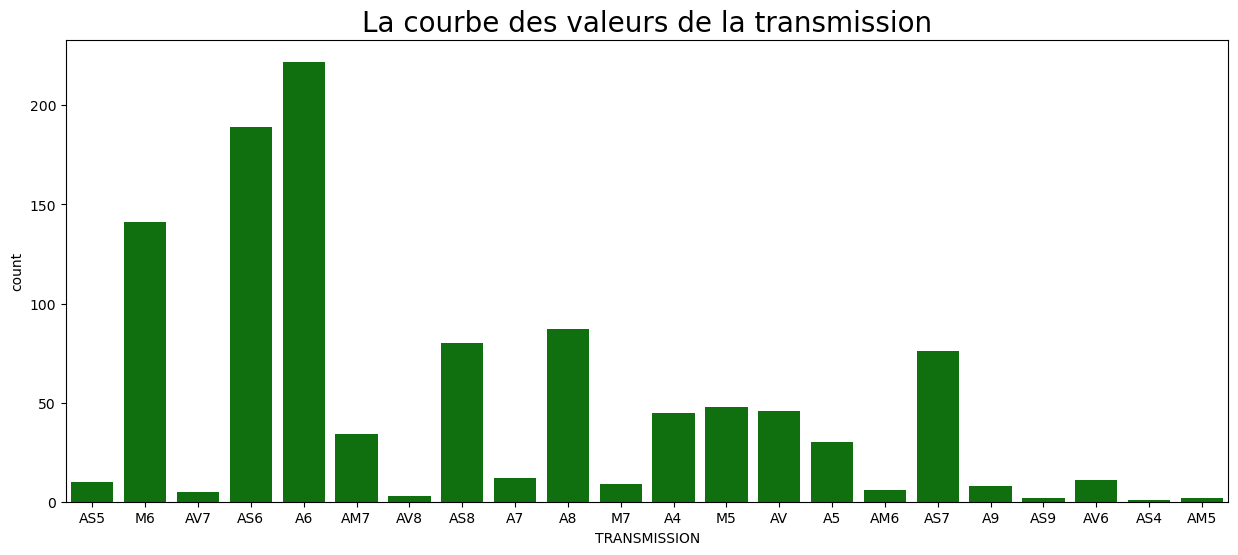

In [7]:
# PLOTE POUR VOIR LES VARIABLES CORRÉLÉÉS
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="TRANSMISSION", color="green")
plt.title("La courbe des valeurs de la transmission", fontsize=20)
plt.show()

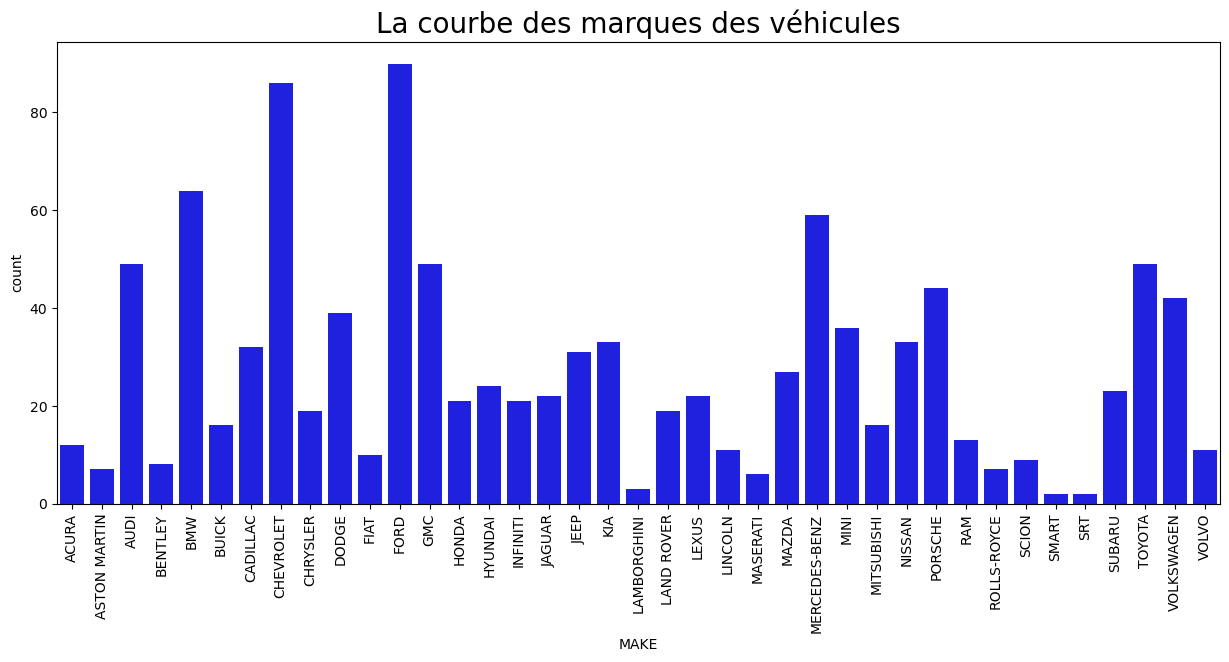

In [8]:
# PLOTE POUR VOIR LES VARIABLES CORRÉLÉÉS
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="MAKE", color="blue")
plt.title("La courbe des marques des véhicules", fontsize=20)
plt.xticks(rotation=90)
plt.show()

In [9]:
# VOIR LES STATISTIQUES DESCRIPTIVES DES VARIABLES CATÉGORIELLES
df_cat.describe(include="object")

,MAKE,MODEL,VEHICLECLASS,TRANSMISSION,FUELTYPE
count,1067,1067,1067,1067,1067
unique,39,663,16,22,4
top,FORD,F150 FFV,MID-SIZE,A6,X
freq,90,8,178,222,514


In [10]:
# LES STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES
df.describe()


,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [11]:
# LES VARIABLES NUMERIQUES
df_num = df.select_dtypes(["number"])
df_num

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,2.0,4,9.9,6.7,8.5,33,196
1,2014,2.4,4,11.2,7.7,9.6,29,221
2,2014,1.5,4,6.0,5.8,5.9,48,136
3,2014,3.5,6,12.7,9.1,11.1,25,255
4,2014,3.5,6,12.1,8.7,10.6,27,244
5,2014,3.5,6,11.9,7.7,10.0,28,230
6,2014,3.5,6,11.8,8.1,10.1,28,232
7,2014,3.7,6,12.8,9.0,11.1,25,255
8,2014,3.7,6,13.4,9.5,11.6,24,267
9,2014,2.4,4,10.6,7.5,9.2,31,212


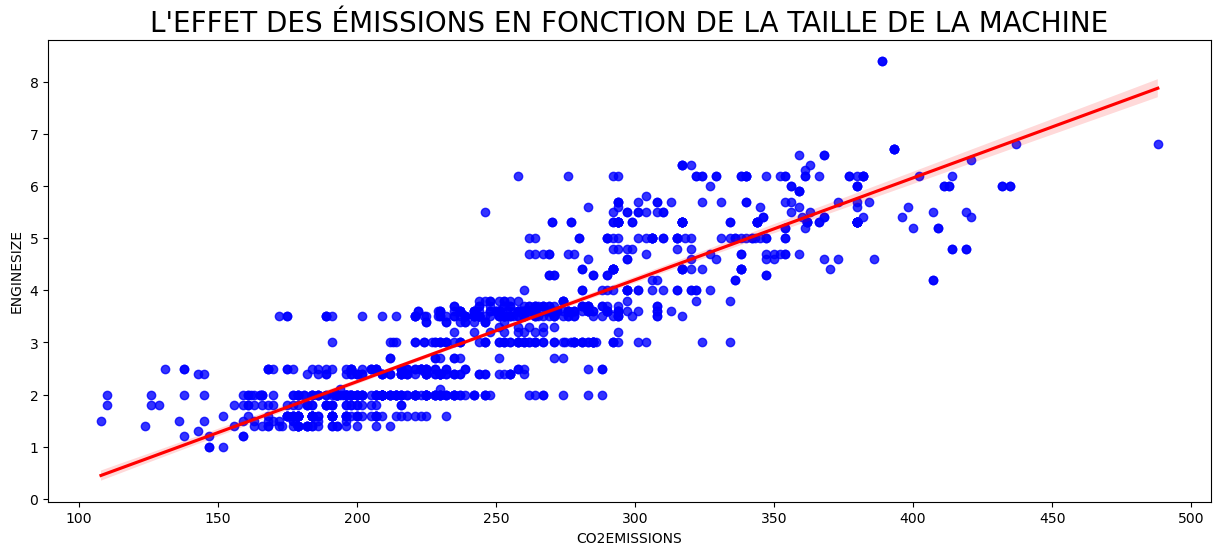

In [12]:
# VOIR LES VARIABLES QUI ONT UNE CORRÉLATION AVEC LA VARIABLE "CO2EMISSIONS"
plt.figure(figsize=(15,6))
sns.regplot(
    x=df["CO2EMISSIONS"],
    y=df["ENGINESIZE"],
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"})

plt.title(
    "L'EFFET DES ÉMISSIONS EN FONCTION DE LA TAILLE DE LA MACHINE",
    fontsize=20)

plt.xlabel("CO2EMISSIONS")
plt.ylabel("ENGINESIZE")

plt.show()

/tmp/ipykernel_46515/776408548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


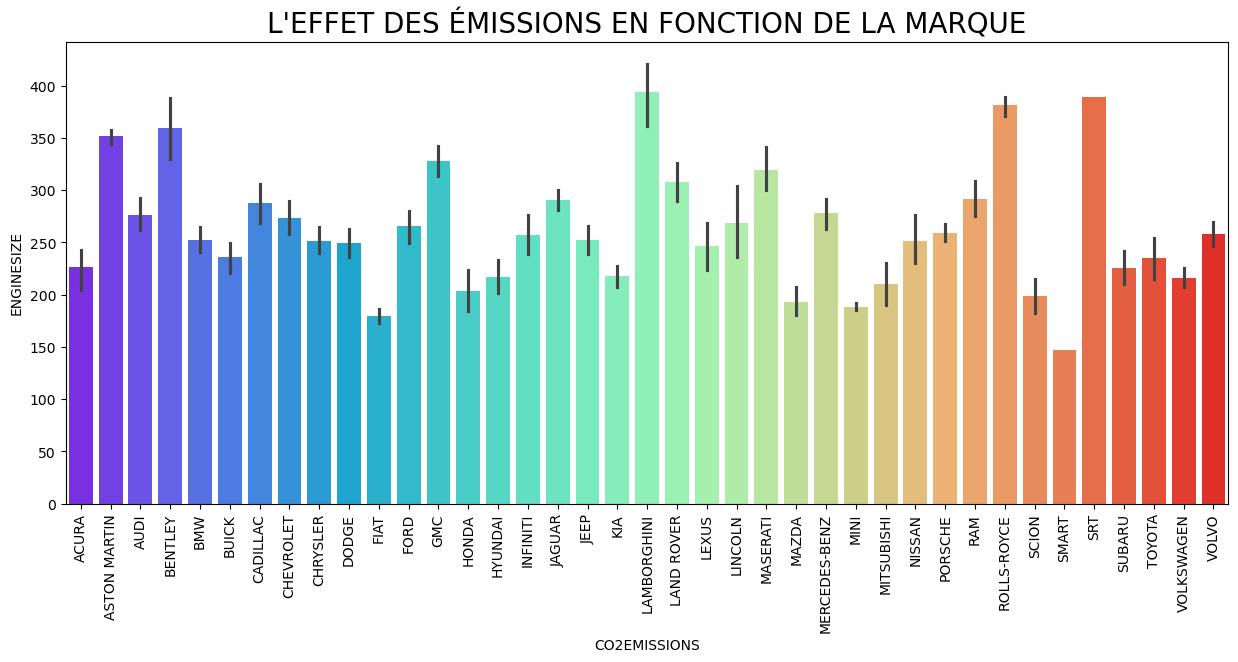

In [13]:
# VOIR LA BOXPLOTE D'UNE VARIABLE CATÉGORIELLE ET LA VARIABLE CIBLE
plt.figure(figsize=(15,6))
sns.barplot(
    x=df["MAKE"],
    y=df["CO2EMISSIONS"],
    # hue="ENGINESIZE",
    palette="rainbow")

plt.title(
    "L'EFFET DES ÉMISSIONS EN FONCTION DE LA MARQUE",
    fontsize=20)

plt.xlabel("CO2EMISSIONS")
plt.xticks(rotation=90)
plt.ylabel("ENGINESIZE")

plt.show()

In [14]:
# GROUPER LES VALEURS PAR LEUR MOYENNE
df_MAKE = df.groupby("MAKE")["CO2EMISSIONS"].sum().reset_index()
df_TRANSMISSION = df.groupby("TRANSMISSION")["CO2EMISSIONS"].sum().reset_index()
df_ENGINESIZE = df.groupby("ENGINESIZE")["CO2EMISSIONS"].sum().reset_index()
df_CYLINDERS = df.groupby("CYLINDERS")["CO2EMISSIONS"].sum().reset_index()

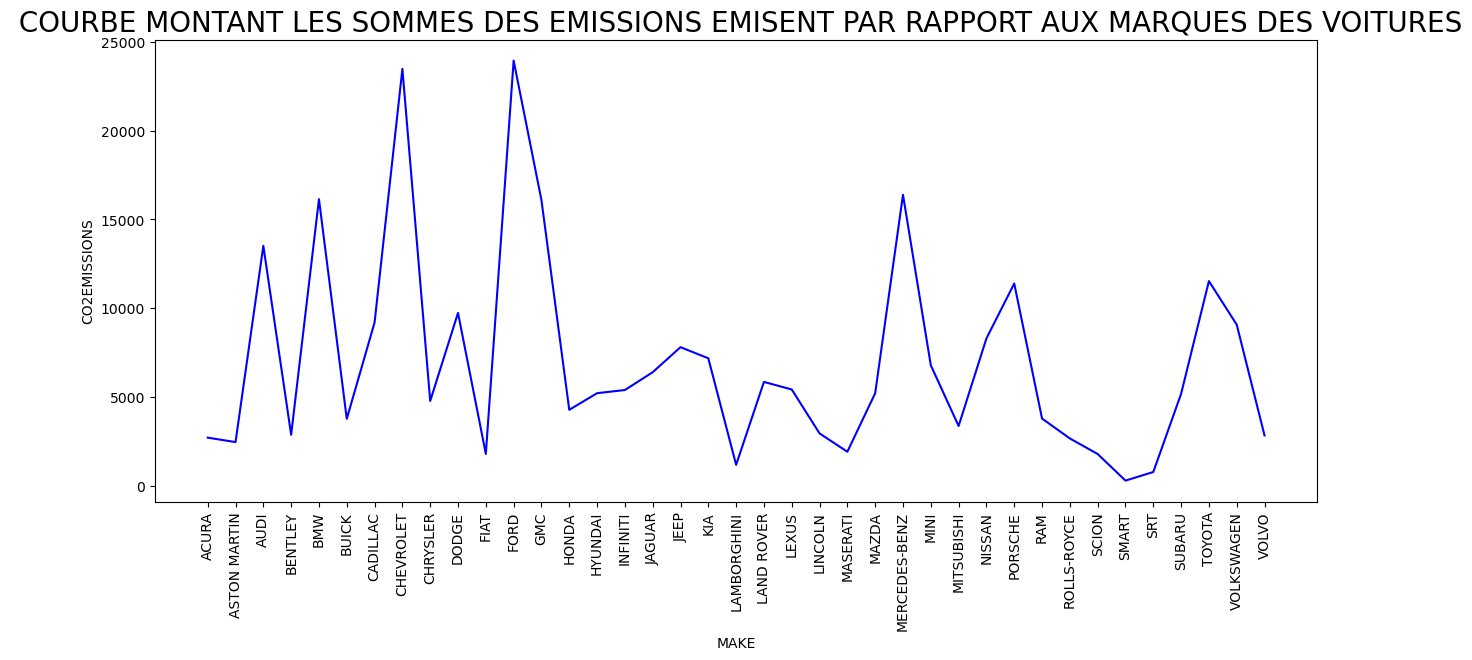

In [15]:
# LES FIGURES
plt.figure(figsize=(15,6))
sns.lineplot(data=df_MAKE, x="MAKE", y="CO2EMISSIONS", color="blue")

plt.title(" COURBE MONTANT LES SOMMES DES EMISSIONS EMISENT PAR RAPPORT AUX MARQUES DES VOITURES", fontsize=20)
plt.xticks(rotation=90)
plt.show()

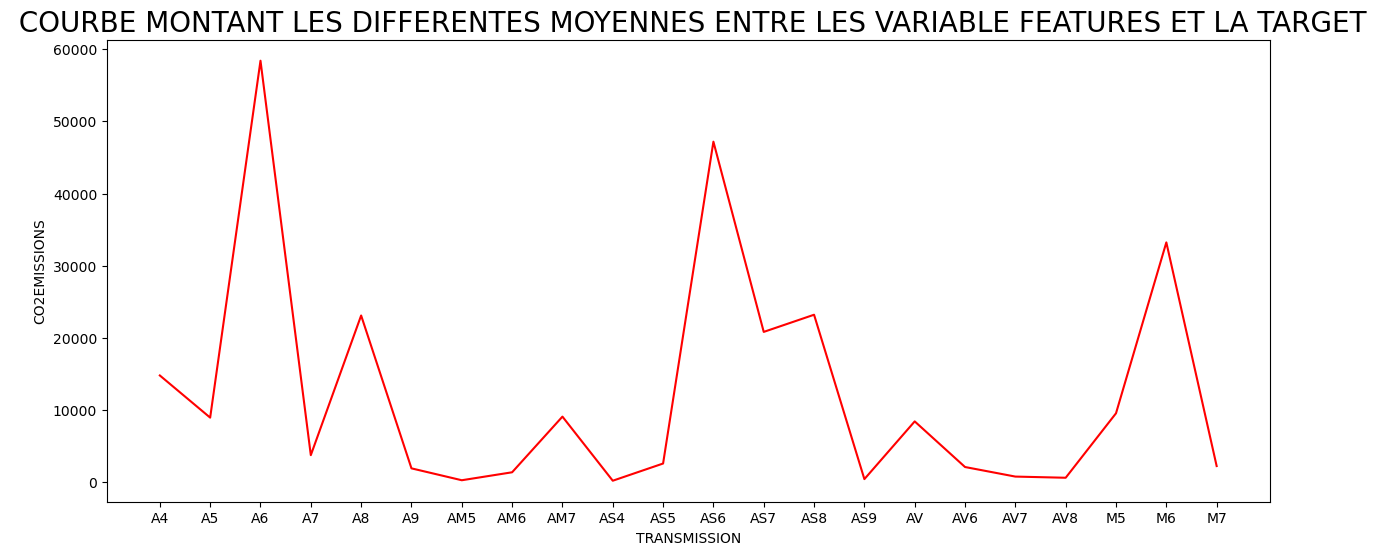

In [16]:
# LES FIGURES
plt.figure(figsize=(15,6))
sns.lineplot(data=df_TRANSMISSION, x="TRANSMISSION", y="CO2EMISSIONS", color="red")

plt.title(" COURBE MONTANT LES DIFFERENTES MOYENNES ENTRE LES VARIABLE FEATURES ET LA TARGET", fontsize=20)
plt.show()

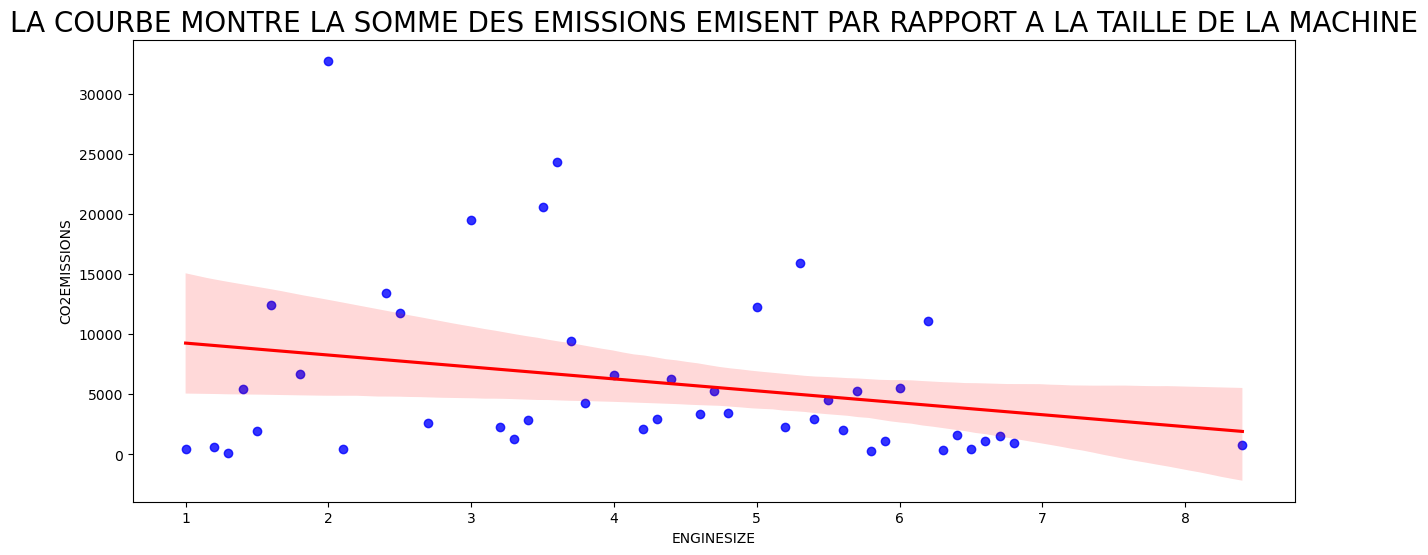

In [17]:
# LES FIGURES
plt.figure(figsize=(15,6))
sns.regplot(data=df_ENGINESIZE, x="ENGINESIZE", y="CO2EMISSIONS", color="pink", scatter_kws={"color":"blue"}, line_kws={"color":"red"})

plt.title("LA COURBE MONTRE LA SOMME DES EMISSIONS EMISENT PAR RAPPORT A LA TAILLE DE LA MACHINE", fontsize=20)
plt.show()

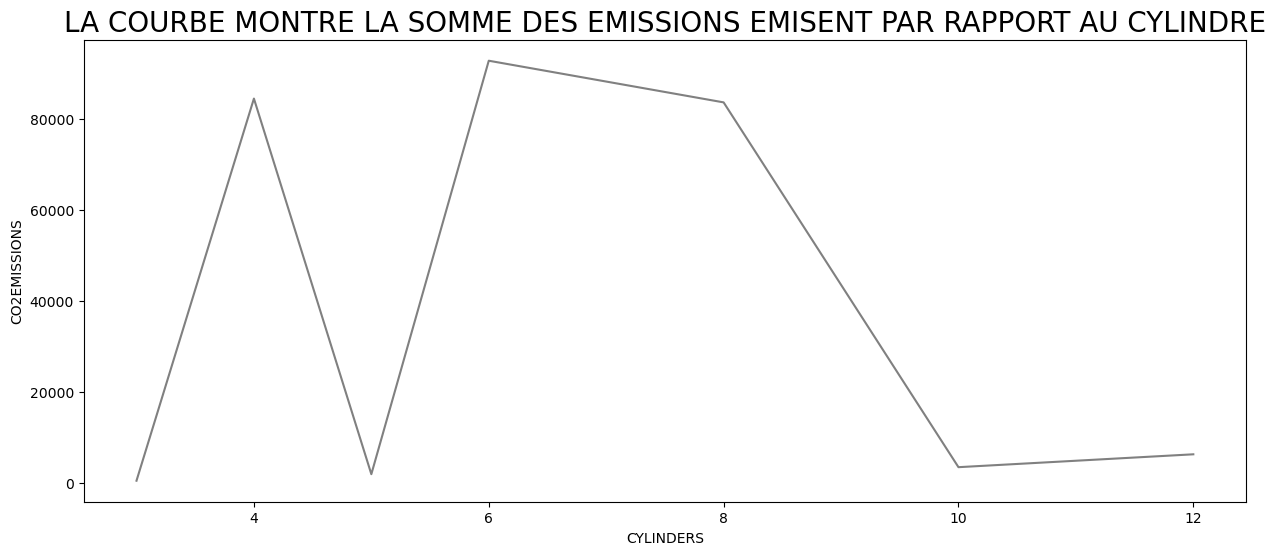

In [18]:
# LES FIGURES
plt.figure(figsize=(15,6))
sns.lineplot(data=df_CYLINDERS, x="CYLINDERS", y="CO2EMISSIONS", color="grey")

plt.title("LA COURBE MONTRE LA SOMME DES EMISSIONS EMISENT PAR RAPPORT AU CYLINDRE", fontsize=20)
plt.show()

## DATA PREPROCESSING

In [19]:
##### SEPARTION DES DONNÉES
X = df_num.drop("CO2EMISSIONS", axis=1)
y = df_num["CO2EMISSIONS"]

# MODÈLE D'ENTRAINEMENT ET MODÈLE DE TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CREATION PUIS ENTRAINEMENT DU MODELE
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Voir le score du modèle
scor = model1.score(X_test, y_test)
print(f"le score de notre moèle est:{scor:.2f}")

le score de notre moèle est:0.90


In [20]:
# FAIRE LA PREDICTION DE MON MODELE
y_p1 = model1.predict(X_test)

# VOIR LES METRIQUES DE LA RÉGRESSION
R2 = r2_score(y_test, y_p1)
MSE = mean_squared_error(y_test, y_p1)
RMSE = root_mean_squared_error(y_test, y_p1)

# AFFICHER CES METRICS
print(f"le score au carré est:{R2:.2f}")
print(f"l'erreur quadratique moyenne est:{MSE:.2f}")
print(f"la racine carré de l'erreur quadratique moyenne:{RMSE:.2f}")

le score au carré est:0.90
l'erreur quadratique moyenne est:399.42
la racine carré de l'erreur quadratique moyenne:19.99


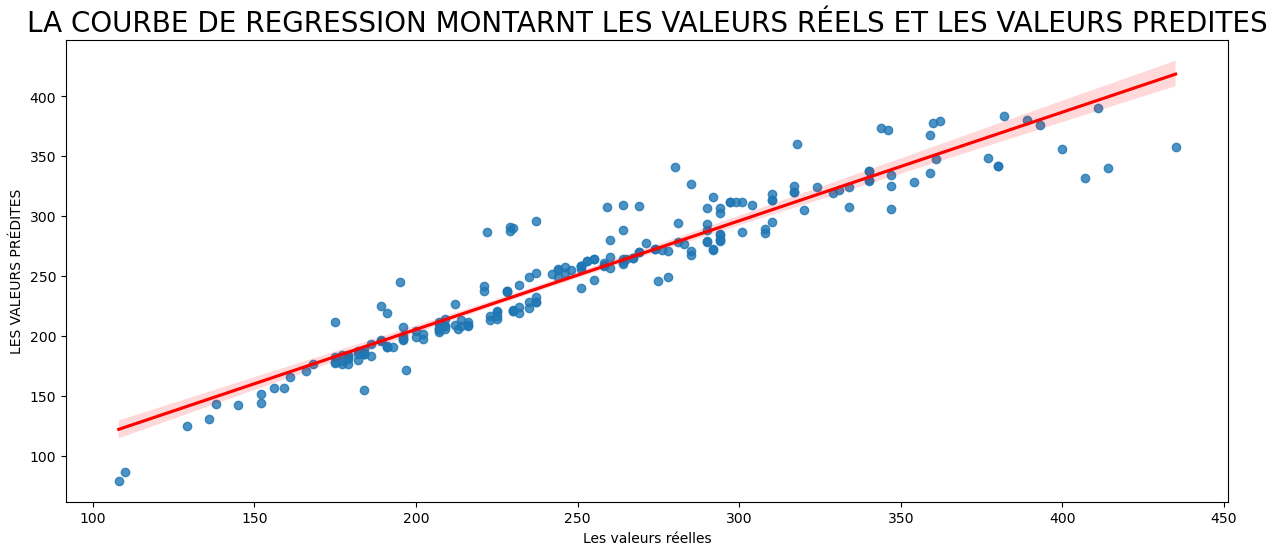

In [21]:
# VOIR LE PLOT
plt.figure(figsize=(15,6))
sns.regplot(x=y_test, y=y_p1, scatter=True, line_kws={"color":"red"})
plt.title("LA COURBE DE REGRESSION MONTARNT LES VALEURS RÉELS ET LES VALEURS PREDITES", fontsize=20)
plt.xlabel("Les valeurs réelles")
plt.ylabel("LES VALEURS PRÉDITES")
plt.show()

# APPLICATION DU MODELE DE RÉGRSSION

In [22]:
# Supprimer MODEL (trop de catégories, peu utile)
df = df.drop(columns=["MODEL"])

In [23]:
# Regrouper VEHICLECLASS (16 → 6 catégories)
regroupement = {
    "MID-SIZE"                 : "BERLINE",
    "COMPACT"                  : "BERLINE",
    "FULL-SIZE"                : "BERLINE",
    "MINICOMPACT"              : "BERLINE",
    "SUBCOMPACT"               : "BERLINE",
    "SUV - SMALL"              : "SUV",
    "SUV - STANDARD"           : "SUV",
    "PICKUP TRUCK - STANDARD"  : "PICKUP",
    "PICKUP TRUCK - SMALL"     : "PICKUP",
    "STATION WAGON - SMALL"    : "BREAK",
    "STATION WAGON - MID-SIZE" : "BREAK",
    "VAN - PASSENGER"          : "VAN",
    "VAN - CARGO"              : "VAN",
    "MINIVAN"                  : "VAN",
    "TWO-SEATER"               : "AUTRE",
    "SPECIAL PURPOSE VEHICLE"  : "AUTRE"
}
df["VEHICLECLASS"] = df["VEHICLECLASS"].map(regroupement)


In [24]:
# Encoder toutes les catégorielles avec get_dummies
CAT_COLS = ["MAKE", "VEHICLECLASS", "TRANSMISSION", "FUELTYPE"]

df = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)

In [28]:
# ÉTAPE 5 — Reprendre le split et le modèle
X = df.drop(columns=["CO2EMISSIONS"])
y = df["CO2EMISSIONS"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
score = lr_model.score(X_test, y_test)
print("Score :", score)

# FAIRE LA PRÉDICTION
y_pred = lr_model.predict(X_test)

Score : 0.9920935163779876


In [30]:
# LES MÉTRIQUES DU MODELE
r2 = r2_score(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = root_mean_squared_error(y_test,y_pred)

print(f"Le r-carré du modèle:{r2}")
print(f"L'erreur quadratique moyenne du modèle:{MSE}")
print(f"La racine carré de l'erreur quadratique moyenne du modèle:{RMSE}")

Le r-carré du modèle:0.9920935163779876
L'erreur quadratique moyenne du modèle:32.69287885329154
La racine carré de l'erreur quadratique moyenne du modèle:5.717768695329633


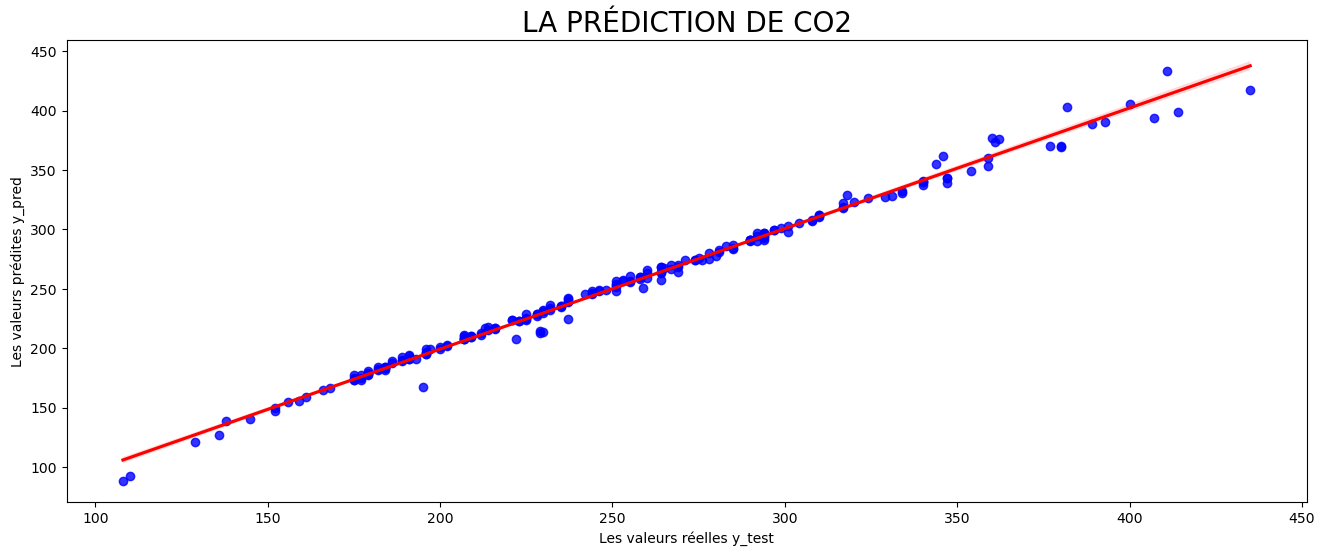

In [33]:
plt.figure(figsize=(16,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"color":"blue"}, line_kws={"color":"red"})
plt.title("LA PRÉDICTION DE CO2", fontsize=20)
plt.xlabel("Les valeurs réelles y_test")
plt.ylabel("Les valeurs prédites y_pred")
plt.show()